In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Risho\Downloads\2.NBA.csv")
print(df.shape)

(12844, 22)


In [3]:
print(df.isnull().sum())

Unnamed: 0              0
player_name             0
team_abbreviation       0
age                     0
player_height           0
player_weight           0
college              1854
country                 0
draft_year              0
draft_round             0
draft_number            0
gp                      0
pts                     0
reb                     0
ast                     0
net_rating              0
oreb_pct                0
dreb_pct                0
usg_pct                 0
ts_pct                  0
ast_pct                 0
season                  0
dtype: int64


In [ ]:


df.dropna()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,12839,Joel Embiid,PHI,29.0,213.36,127.005760,Kansas,Cameroon,2014,1,...,33.1,10.2,4.2,8.8,0.057,0.243,0.370,0.655,0.233,2022-23
12840,12840,John Butler Jr.,POR,20.0,213.36,86.182480,Florida State,USA,Undrafted,Undrafted,...,2.4,0.9,0.6,-16.1,0.012,0.065,0.102,0.411,0.066,2022-23
12841,12841,John Collins,ATL,25.0,205.74,102.511792,Wake Forest,USA,2017,1,...,13.1,6.5,1.2,-0.2,0.035,0.180,0.168,0.593,0.052,2022-23
12842,12842,Jericho Sims,NYK,24.0,208.28,113.398000,Texas,USA,2021,2,...,3.4,4.7,0.5,-6.7,0.117,0.175,0.074,0.780,0.044,2022-23


In [9]:
#outlier detection
from scipy import stats
numerical=df[['age','player_height','player_weight','draft_round','draft_number','gp','pts','reb','ast','net_rating','oreb_pct','dreb_pct','usg_pct','ts_pct','ast_pct']]
#sometimes some numerical fields can be 'NA'
numerical = numerical.apply(pd.to_numeric, errors='coerce')
zscore=stats.zscore(numerical)
outlier=(zscore>3).all(axis=1)
df=df[~outlier]
df.shape

(12844, 22)

In [10]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numerical=scaler.fit_transform(numerical)
df.head()

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


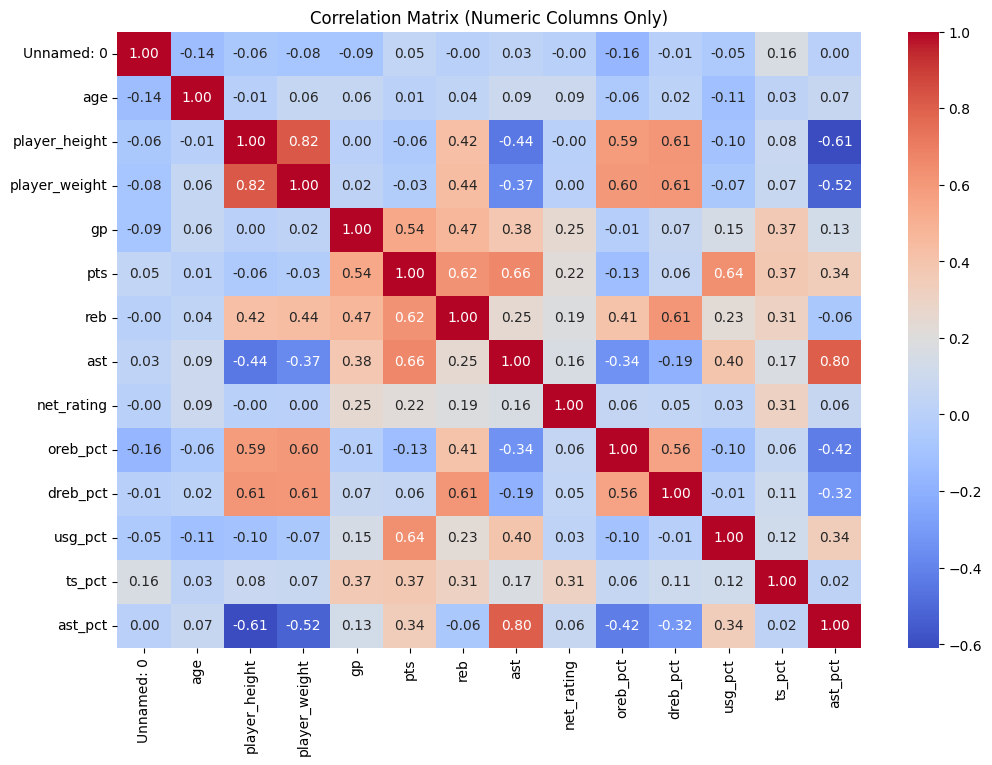

In [ ]:
#to find which two elements are best related use corr matrix and only after that find the regression line
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numeric Columns Only)")
plt.show()


Regression equation: y = 0.6028 * x + 140.1178


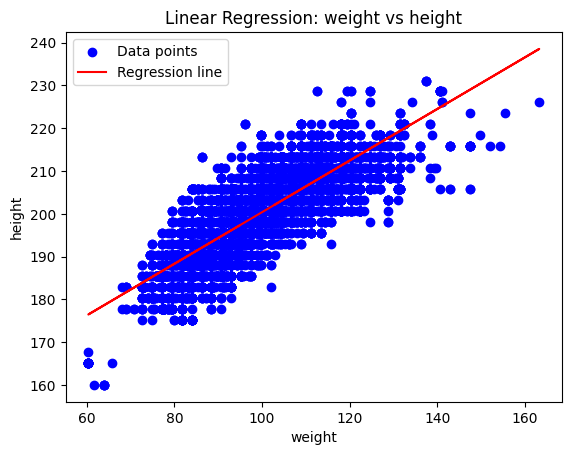

In [16]:
#Generate the regression equation and line.
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Independent variable (X) and target (y)
X = df[['player_weight']]   # predictor
y = df['player_height']     # target
model=LinearRegression()
model.fit(X,y)
slope=model.coef_[0]
intercept=model.intercept_
print(f"Regression equation: y = {slope:.4f} * x + {intercept:.4f}")
y_pred = model.predict(X)
#to plot
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred, color='red', label='Regression line')
plt.xlabel("weight")
plt.ylabel("height")
plt.title("Linear Regression: weight vs height")
plt.legend()
plt.show()



In [20]:
#Split the dataset into training and testing sets. 
#4. Build a linear regression model and train it on the training set. 
#5. Use the trained model to make predictions on the testing set.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Step 1: Keep only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Step 2: Define features (X) and target (y)
# Example: predict 'pts' using all other numeric columns
X = numeric_df.drop(columns=['player_height'])
y = numeric_df['player_height']

# Step 3: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Predict
y_pred = model.predict(X_test)
print(y_pred)


# Optional: Show coefficients
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coeff_df)


[202.02685559 195.64130688 211.18244959 ... 212.66935735 208.65052253
 204.86179462]
          Feature  Coefficient
0      Unnamed: 0    -0.000031
1             age    -0.058099
2   player_weight     0.406534
3              gp    -0.008360
4             pts     0.046808
5             reb     0.266460
6             ast    -0.237167
7      net_rating    -0.008874
8        oreb_pct     8.359792
9        dreb_pct    19.109649
10        usg_pct    -1.327937
11         ts_pct     1.412450
12        ast_pct   -21.080837


In [21]:
#Calculate metrics like mean squared error (MSE), root mean squared error (RMSE), 
#mean absolute error (MAE), and R-squared to evaluate the model's performance.
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# R-squared (R²)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Mean Squared Error (MSE): 20.8685
Root Mean Squared Error (RMSE): 4.5682
Mean Absolute Error (MAE): 3.5986
R-squared (R²): 0.7480


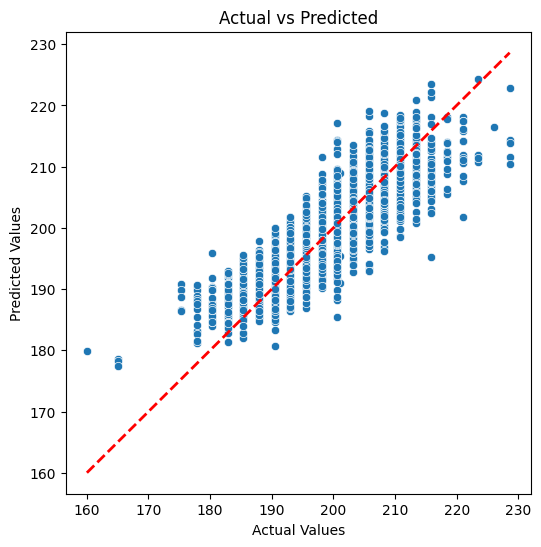

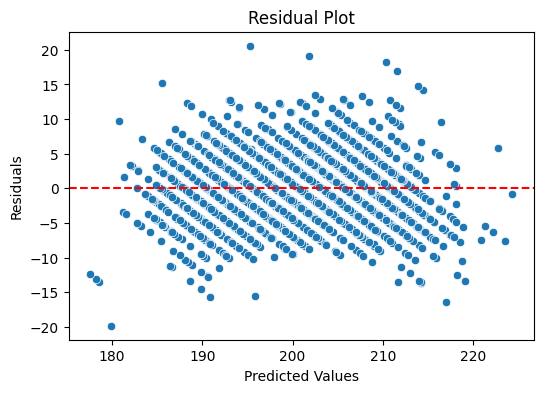

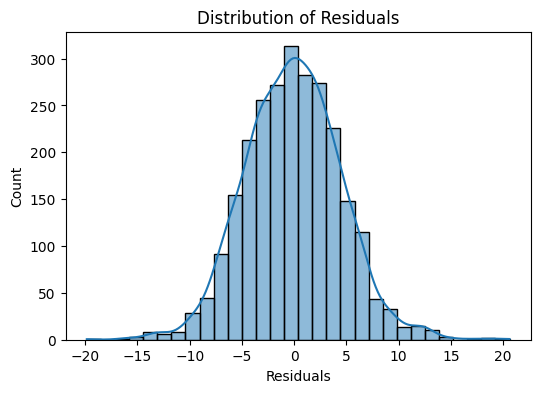

In [22]:
#Create plots (e.g., scatter plots, residual plots) to visualize the model's fit and identify potential issues. 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming y_test and y_pred are already available
# Calculate residuals
residuals = y_test - y_pred

# 1. Scatter Plot - Actual vs. Predicted
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # perfect fit line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

# 2. Residual Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# 3. Histogram of Residuals
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()


In [25]:
feature_names = X_train.columns.tolist()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=lambda x: abs(x), ascending=False)

print("\nTop 10 Important Features:")
print(coef_df.head(10))



Top 10 Important Features:
          Feature  Coefficient
12        ast_pct   -21.080837
9        dreb_pct    19.109649
8        oreb_pct     8.359792
11         ts_pct     1.412450
10        usg_pct    -1.327937
2   player_weight     0.406534
5             reb     0.266460
6             ast    -0.237167
1             age    -0.058099
4             pts     0.046808


#Discuss the model's performance and various other inferences.
The linear regression model predicting points (pts) showed limited accuracy, 
with low R² indicating it explains only a small portion of the variation in scoring. 
Features like games played, usage percentage, and true shooting percentage were the 
strongest predictors, while static attributes like age or height had minimal impact. 
This suggests that in-game performance metrics are more influential than demographic data, 
and the model could benefit from additional contextual features to improve predictions.